### Reading in Dataset

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("osmi/mental-health-in-tech-survey")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mental-health-in-tech-survey' dataset.
Path to dataset files: /kaggle/input/mental-health-in-tech-survey


In [6]:
df = pd.read_csv('/kaggle/input/mental-health-in-tech-survey/survey.csv')

In [7]:
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [8]:
print(df.isnull().sum())

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64


### Data Cleaning

In [9]:
# looking at values for age
print(df['Age'].describe())
print(sorted(df['Age'].unique().tolist()))

count    1.259000e+03
mean     7.942815e+07
std      2.818299e+09
min     -1.726000e+03
25%      2.700000e+01
50%      3.100000e+01
75%      3.600000e+01
max      1.000000e+11
Name: Age, dtype: float64
[-1726, -29, -1, 5, 8, 11, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 53, 54, 55, 56, 57, 58, 60, 61, 62, 65, 72, 329, 99999999999]


In [10]:
# keeping only what makes sense
df = df[df['Age'].between(18, 75)]

# checking
print(df['Age'].describe())
print(df['Age'].unique())

count    1251.000000
mean       32.076739
std         7.288272
min        18.000000
25%        27.000000
50%        31.000000
75%        36.000000
max        72.000000
Name: Age, dtype: float64
[37 44 32 31 33 35 39 42 23 29 36 27 46 41 34 30 40 38 50 24 18 28 26 22
 19 25 45 21 43 56 60 54 55 48 20 57 58 47 62 51 65 49 53 61 72]


In [11]:
# looking at values for gender
print(df['Gender'].value_counts())

Gender
Male                                              612
male                                              204
Female                                            121
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Woman                                               3
Male                                                3
Female                                              2
Cis Male                                            2
Man                                                 2
Female (trans)                                      2
something kinda male?                               1
Trans-female                                        1
Cis Female                                          1
Male-ish             

In [12]:
# combined to four categories
male_list = [
    'Male', 'male', 'M', 'm', 'Make', 'Man', 'Cis Male', 'Male (CIS)',
    'cis male', 'Cis Man', 'Male-ish', 'maile', 'Mal', 'Malr', 'msle',
    'Malr', 'Mail', 'male leaning androgynous',
    'something kinda male?', 'Guy (-ish) ^_^',
    'ostensibly male, unsure what that really means'
]

female_list = [
    'Female', 'female', 'F', 'f', 'Woman', 'woman', 'Cis Female',
    'Female (cis)', 'cis-female/femme', 'Femake', 'femail',
    'Trans-female', 'Trans woman', 'Female (trans)'
]

nonbinary_list = [
    'non-binary', 'Enby', 'queer/she/they', 'Neuter'
]

# apply to gender column
def clean_gender(g):
    if g in male_list:
        return 'Male'
    elif g in female_list:
        return 'Female'
    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

print(df['Gender'].value_counts())

Gender
Male      987
Female    249
Other      15
Name: count, dtype: int64


In [13]:
# fill blanks in work interference, since not applicable for those without medical condition
df['work_interfere'] = df['work_interfere'].fillna('Not Applicable')

print(df['work_interfere'].value_counts())

work_interfere
Sometimes         464
Not Applicable    262
Never             212
Rarely            173
Often             140
Name: count, dtype: int64


In [14]:
# drop self-employed nulls
df = df.dropna(subset=['self_employed'])
print(df['self_employed'].value_counts())

self_employed
No     1091
Yes     142
Name: count, dtype: int64


In [15]:
# looking at country values
print(df['Country'].value_counts())

Country
United States             735
United Kingdom            182
Canada                     68
Germany                    45
Netherlands                27
Ireland                    27
Australia                  21
France                     13
India                      10
New Zealand                 8
Sweden                      7
Poland                      7
Switzerland                 7
Italy                       7
Brazil                      6
South Africa                6
Belgium                     6
Israel                      5
Singapore                   4
Bulgaria                    3
Russia                      3
Mexico                      3
Finland                     3
Austria                     3
Denmark                     2
Portugal                    2
Colombia                    2
Croatia                     2
Greece                      2
Slovenia                    1
Uruguay                     1
Spain                       1
Latvia                      1
Ro

### Wellbeing Score

In [16]:
# choose wellbeing columns
# what is actionable for the employer and how they handle the workplace
wellbeing_cols = [
    'benefits', 'care_options', 'wellness_program', 'seek_help',
    'anonymity', 'leave', 'mental_health_consequence',
    'mental_vs_physical', 'obs_consequence'
]

# check values
for col in wellbeing_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


benefits:
benefits
Yes           466
Don't know    400
No            367
Name: count, dtype: int64

care_options:
care_options
No          492
Yes         434
Not sure    307
Name: count, dtype: int64

wellness_program:
wellness_program
No            824
Yes           227
Don't know    182
Name: count, dtype: int64

seek_help:
seek_help
No            632
Don't know    355
Yes           246
Name: count, dtype: int64

anonymity:
anonymity
Don't know    802
Yes           370
No             61
Name: count, dtype: int64

leave:
leave
Don't know            552
Somewhat easy         262
Very easy             202
Somewhat difficult    121
Very difficult         96
Name: count, dtype: int64

mental_health_consequence:
mental_health_consequence
No       476
Maybe    471
Yes      286
Name: count, dtype: int64

mental_vs_physical:
mental_vs_physical
Don't know    566
Yes           336
No            331
Name: count, dtype: int64

obs_consequence:
obs_consequence
No     1054
Yes     179
Name: count

In [17]:
def score_row(row):
    score = 0

    # benefits
    score += {'Yes': 1, "Don't know": 0.5, 'No': 0}.get(row['benefits'], 0.5)

    # care options
    score += {'Yes': 1, 'Not sure': 0.5, 'No': 0}.get(row['care_options'], 0.5)

    # wellness program
    score += {'Yes': 1, "Don't know": 0.5, 'No': 0}.get(row['wellness_program'], 0.5)

    # seek help resources
    score += {'Yes': 1, "Don't know": 0.5, 'No': 0}.get(row['seek_help'], 0.5)

    # anonymity
    score += {'Yes': 1, "Don't know": 0.5, 'No': 0}.get(row['anonymity'], 0.5)

    # leave
    score += {
        'Very easy': 1,
        'Somewhat easy': 0.75,
        "Don't know": 0.5,
        'Somewhat difficult': 0.25,
        'Very difficult': 0
    }.get(row['leave'], 0.5)

    # mental health consequence (No = good)
    score += {'No': 1, 'Maybe': 0.5, 'Yes': 0}.get(row['mental_health_consequence'], 0.5)

    # mental vs physical parity
    score += {'Yes': 1, "Don't know": 0.5, 'No': 0}.get(row['mental_vs_physical'], 0.5)

    # observed consequence (No = good)
    score += {'No': 1, 'Yes': 0}.get(row['obs_consequence'], 0.5)

    return score

df['composite_score'] = df.apply(score_row, axis=1)

print(df['composite_score'].describe())

count    1233.000000
mean        4.748783
std         1.782997
min         0.000000
25%         3.500000
50%         4.500000
75%         6.000000
max         9.000000
Name: composite_score, dtype: float64


count    1233.000000
mean        4.748783
std         1.782997
min         0.000000
25%         3.500000
50%         4.500000
75%         6.000000
max         9.000000
Name: composite_score, dtype: float64


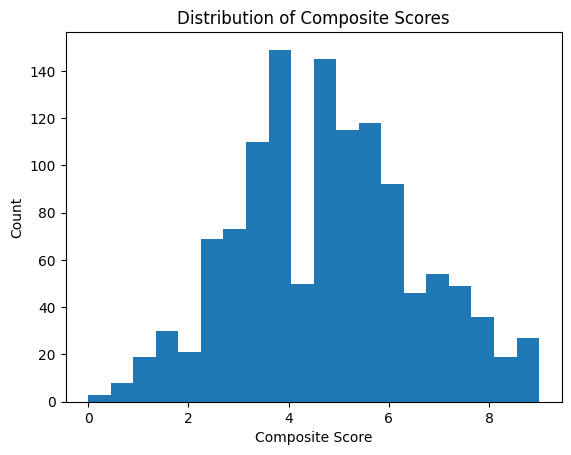

In [18]:
# look at distribution to determine the fitting statistical tests
print(df['composite_score'].describe())

plt.hist(df['composite_score'], bins=20)
plt.xlabel('Composite Score')
plt.ylabel('Count')
plt.title('Distribution of Composite Scores')
plt.show()

In [19]:
# Percentile-based, let the data decide
t1 = df['composite_score'].quantile(0.67)  # top third
t2 = df['composite_score'].quantile(0.33)  # bottom third

print(f"Tier 1 cutoff (high support): above {t1}")
print(f"Tier 2 cutoff (moderate): {t2} to {t1}")
print(f"Tier 3 cutoff (low support): below {t2}")

Tier 1 cutoff (high support): above 5.5
Tier 2 cutoff (moderate): 4.0 to 5.5
Tier 3 cutoff (low support): below 4.0


In [20]:
# using the percentile-based cutoffs
def assign_tier(score):
    if score > 5.5:
        return 'Tier 1 - High Support'
    elif score >= 4.0:
        return 'Tier 2 - Moderate Support'
    else:
        return 'Tier 3 - Low Support'

df['tier'] = df['composite_score'].apply(assign_tier)

print(df['tier'].value_counts())

tier
Tier 2 - Moderate Support    506
Tier 3 - Low Support         374
Tier 1 - High Support        353
Name: count, dtype: int64


In [21]:
# statistical test
from scipy import stats

seg_vars = [
    'Gender',
    'no_employees',
    'Country'
]

results = {}

for var in seg_vars:
    groups = [group['composite_score'].values
              for name, group in df.groupby(var)]
    stat, p = stats.kruskal(*groups)
    results[var] = {'stat': round(stat, 3), 'p_value': round(p, 4)}

In [22]:
results_df = pd.DataFrame(results).T
results_df['significant'] = results_df['p_value'] < 0.05
print(results_df.sort_values('p_value'))

                 stat  p_value  significant
no_employees   86.661   0.0000         True
Country       154.123   0.0000         True
Gender          3.534   0.1708        False


In [23]:
from scipy.stats import mannwhitneyu

mw_results = {}

binary_vars = ['remote_work', 'self_employed', 'tech_company', 'treatment', 'family_history']

for var in binary_vars:
    groups = [group['composite_score'].values
              for name, group in df.groupby(var)]
    stat, p = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
    mw_results[var] = {'stat': round(stat, 3), 'p_value': round(p, 4)}

mw_results_df = pd.DataFrame(mw_results).T
mw_results_df['significant'] = mw_results_df['p_value'] < 0.05
print(mw_results_df.sort_values('p_value'))

                    stat  p_value  significant
treatment       177973.5   0.0537        False
self_employed    82455.0   0.2103        False
family_history  173813.0   0.2388        False
tech_company    115875.0   0.5516        False
remote_work     160987.0   0.6512        False


### First Viz: Overall Distribution

In [24]:
print(df['tech_company'].value_counts())

tech_company
Yes    1009
No      224
Name: count, dtype: int64


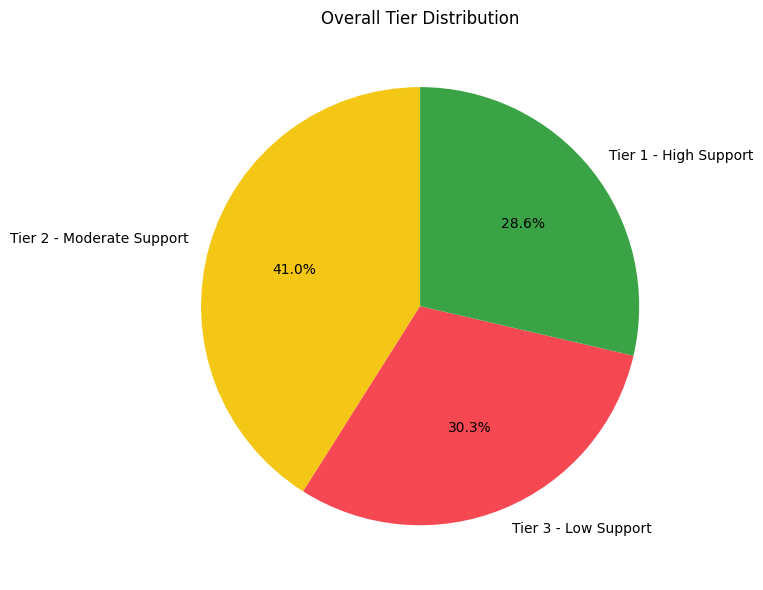

In [25]:
tier_counts = df['tier'].value_counts()

colors = ['#f4c717', '#f64852', '#3aa346']  # green, orange, red
labels = tier_counts.index
sizes = tier_counts.values

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)

ax.set_title('Overall Tier Distribution')
plt.tight_layout()
plt.show()

In [26]:
# save cleaned data to create interactive visualizatoin on tableau
df.to_csv('survey_cleaned.csv', index=False)

## Second Viz: Score Distribution across Segmentation Variables

/tmp/ipykernel_2815/1142547485.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups, vert=True)


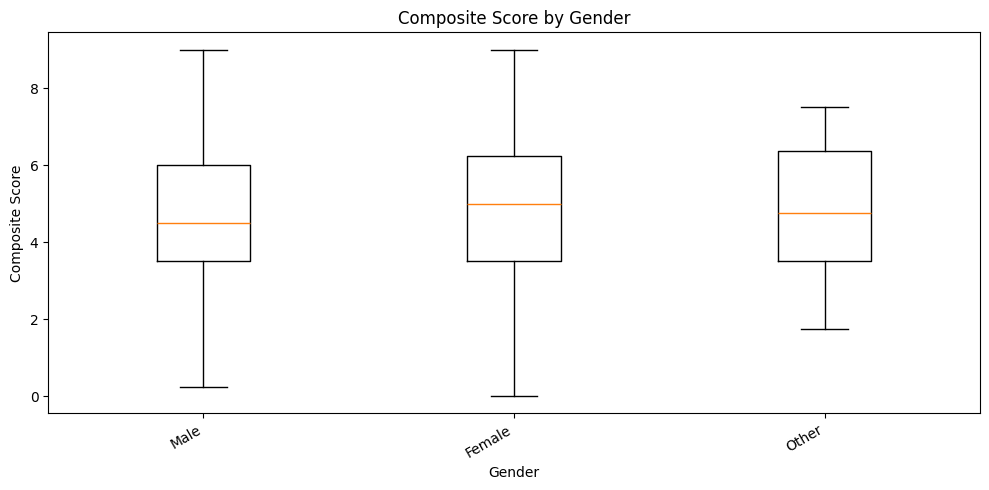

In [27]:
# box plot (score distribution - gender)
seg_var = 'Gender'
groups = df[seg_var].unique()
data = [df[df[seg_var] == g]['composite_score'].values for g in groups]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data, labels=groups, vert=True)

ax.set_title(f'Composite Score by {seg_var}')
ax.set_ylabel('Composite Score')
ax.set_xlabel(seg_var)

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2815/3923149750.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, vert=True)


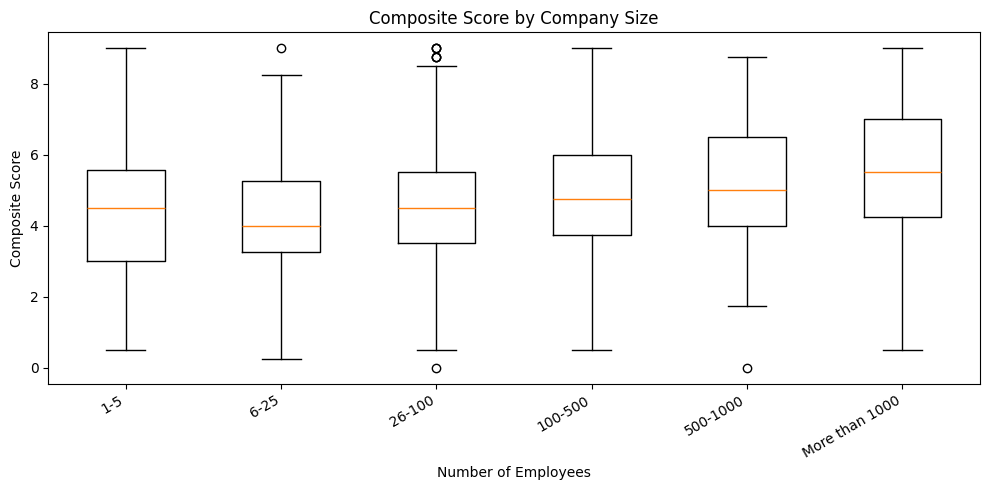

In [28]:
#
order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']

# filter to only sizes that actually exist in data
order = [g for g in order if g in df['no_employees'].values]
data = [df[df['no_employees'] == g]['composite_score'].values for g in order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data, labels=order, vert=True)

ax.set_title('Composite Score by Company Size')
ax.set_ylabel('Composite Score')
ax.set_xlabel('Number of Employees')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


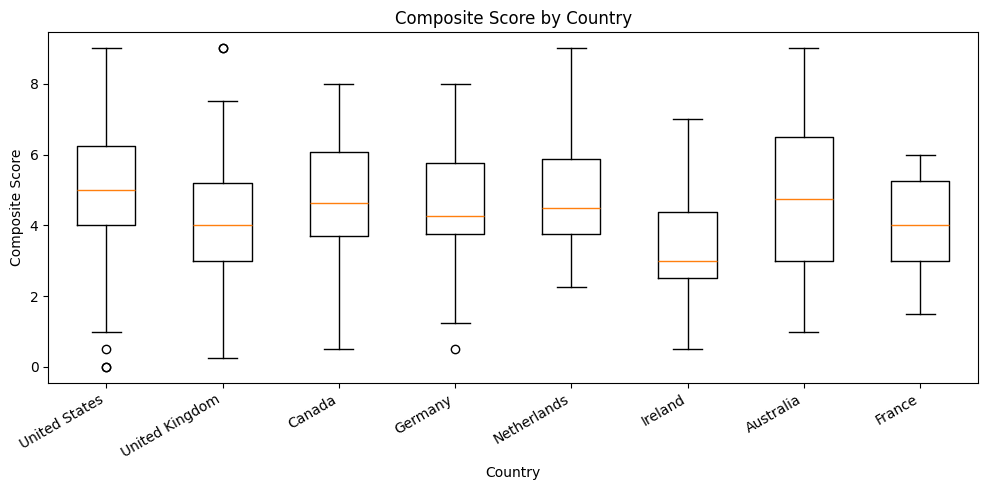

In [29]:
# box plot (score distribution - top 8 countries)
top_countries = df['Country'].value_counts().head(8).index
df_top = df[df['Country'].isin(top_countries)]

country_data = [df_top[df_top['Country'] == country]['composite_score'].values for country in top_countries]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(country_data, tick_labels=top_countries, vert=True)

ax.set_title('Composite Score by Country')
ax.set_ylabel('Composite Score')
ax.set_xlabel('Country')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()